# Lab 7 — OFDM: From the IFFT to the 5G NR Resource Grid

**Companion to Chapter 17** (*OFDM and Multicarrier*).
**Time needed:** about 75 minutes. **Difficulty:** core.

Lab 6 showed how hard it is to equalize a wideband single-carrier signal. OFDM's answer is
to not have a wideband signal at all: split the band into hundreds of narrow subcarriers,
each so narrow that the channel looks flat across it, and use an FFT to do it cheaply. A
cyclic prefix turns the channel's linear convolution into a circular one, and equalization
collapses to one complex division per subcarrier. Wi-Fi, LTE, 5G NR, DVB-T, DSL and
DOCSIS 3.1 all rest on this idea. This lab builds it, breaks it on purpose, and fixes it.

### What you will learn
1. See why subcarriers spaced by $1/T$ are orthogonal despite overlapping spectra.
2. Show how the cyclic prefix enables one-tap equalization, and what happens when it is too short.
3. Quantify inter-carrier interference from CFO and Doppler.
4. Acquire timing and CFO with a Schmidl–Cox preamble; estimate the channel from comb pilots.
5. Compare the PAPR of CP-OFDM, DFT-s-OFDM and single carrier; work with NR numerologies.

### Prerequisites
Labs 5 and 6 (multipath channels, equalization). The DFT and circular convolution (Chapter 2).

### Roadmap
| § | Topic | Interactive |
|---|-------|:-----------:|
| 1 | Orthogonal subcarriers | |
| 2 | One-tap equalization thanks to the cyclic prefix | yes |
| 3 | CFO destroys orthogonality | |
| 4 | Timing and CFO acquisition (Schmidl & Cox) | |
| 5 | Pilot-based channel estimation | |
| 6 | PAPR: why the uplink uses DFT-spread OFDM | |
| 7 | 5G NR numerology | |

In [1]:
import os, sys
os.environ.setdefault("OPENBLAS_NUM_THREADS", "2")   # small matrices: avoid BLAS thread thrashing
sys.path[:0] = [p for p in (os.path.abspath(".."), os.path.abspath("."))
                if os.path.isdir(os.path.join(p, "commlib"))]
import numpy as np
import matplotlib.pyplot as plt
import commlib as cl
from commlib import labkit as lk

rng = lk.setup(seed=7, lab="07")
q16 = cl.get_constellation("16qam")
fs = 15.36e6                                   # LTE 10 MHz sampling rate

Lab 07 ready | numpy 2.5.3 | scipy 1.18.1 | matplotlib 3.11.2 | seed 7


## 1. Orthogonal subcarriers

Subcarrier $k$ is $e^{j2\pi k t/T}$ on $0 \le t < T$. Each one's spectrum is a sinc centred at
$k/T$ with zeros at every *other* multiple of $1/T$, so sampling the spectrum at $k/T$ sees
only subcarrier $k$: the subcarriers overlap heavily and still do not interfere. The IFFT
generates all of them at once; the FFT at the receiver separates them.

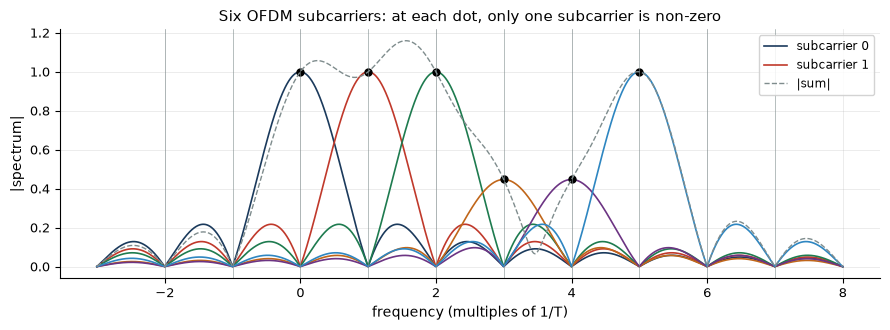

In [3]:
fr = np.linspace(-3, 8, 2000)
f, ax = lk.fig("wide")
tot = np.zeros_like(fr, dtype=complex)
syms = q16.modulate(cl.random_bits(4 * 6, rng))
for k in range(6):
    sk = syms[k] * np.sinc(fr - k)
    tot += sk
    ax.plot(fr, np.abs(sk), lw=1.2, label=f"subcarrier {k}" if k < 2 else None)
    ax.plot(k, np.abs(syms[k]), "o", color="k", ms=5)
ax.plot(fr, np.abs(tot), color=lk.GRAY, ls="--", lw=1, label="|sum|")
for k in range(-2, 8):
    ax.axvline(k, color=lk.GRAY, lw=0.4)
ax.set_xlabel("frequency (multiples of 1/T)"); ax.set_ylabel("|spectrum|"); ax.legend(loc="upper right")
ax.set_title("Six OFDM subcarriers: at each dot, only one subcarrier is non-zero")
lk.show(f)

**What you should see.** At every integer frequency (the dots) one sinc peaks and all the
others cross zero. Shift the FFT sampling grid (a frequency offset) and that property is lost:
Section 3.

## 2. One-tap equalization thanks to the cyclic prefix

With a cyclic prefix at least as long as the channel memory, the received subcarrier $k$ is

$$Y_k = H_k X_k + W_k ,$$

where $H_k$ is the channel's DFT. We use the LTE EVA profile at 15.36 MS/s (up to 2.51 µs of
delay, about 39 samples) with a 72-sample CP and 600 active subcarriers of 15 kHz.

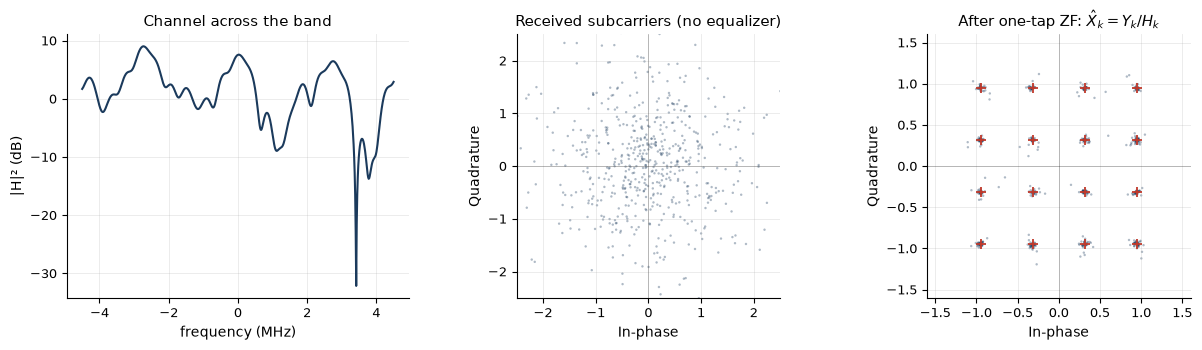

In [6]:
cfg = cl.OFDMConfig(nfft=1024, n_used=600, ncp=72)
nsym = 14
grid = q16.modulate(cl.random_bits(4 * 600 * nsym, rng)).reshape(nsym, 600)
x = cl.ofdm_modulate(grid, cfg)
y, taps = cl.tdl_channel(x, fs, "EVA", fd_hz=5, rng=rng, return_taps=True)
y = cl.awgn(y[:len(x)], 30, rng)
Y = cl.ofdm_demodulate(y, cfg)
H = np.fft.fft(taps[cfg.ncp], cfg.nfft)[cfg.active]       # channel during the first symbol
Z = Y / H
f, ax = lk.fig("row3", 1, 3)
ax[0].plot(cfg.k * fs / cfg.nfft / 1e6, lk.db(np.abs(H) ** 2)); ax[0].set_xlabel("frequency (MHz)")
ax[0].set_ylabel("|H|² (dB)"); ax[0].set_title("Channel across the band")
lk.constellation(ax[1], Y[0], title="Received subcarriers (no equalizer)", lim=2.5)
lk.constellation(ax[2], Z[0], q16.points, "After one-tap ZF: $\\hat X_k = Y_k / H_k$", lim=1.6)
lk.show(f)

**What you should see.** Fades of 20 dB and more across the band; received subcarriers
scattered in amplitude and phase; and after a single division per subcarrier, a clean 16-QAM
constellation (noisier on the faded subcarriers, which Lab 8's coding will protect).

### Interactive: cyclic prefix versus delay spread
Shrink the CP below the channel's maximum excess delay and watch ISI and ICI raise the EVM
floor even at high SNR.

[info] Interactive panel, shown here at its default settings: run the notebook in Jupyter to move the controls.

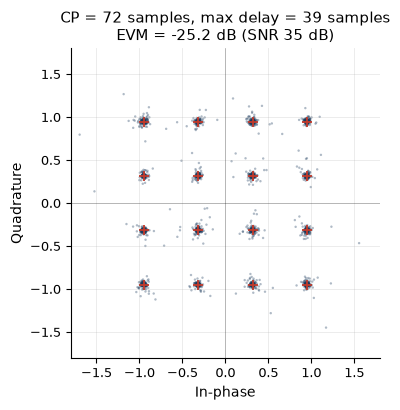

In [8]:
def cp_demo(ncp=72, profile="EVA", snr_db=35.0):
    c = cl.OFDMConfig(1024, 600, ncp)
    g = q16.modulate(cl.random_bits(4 * 600 * 8, rng)).reshape(8, 600)
    xx = cl.ofdm_modulate(g, c)
    yy, tp = cl.tdl_channel(xx, fs, profile, fd_hz=1, rng=rng, return_taps=True)
    yy = cl.awgn(yy[:len(xx)], snr_db, rng)
    YY = cl.ofdm_demodulate(yy, c)
    HH = np.array([np.fft.fft(tp[s * c.sym_len + ncp], 1024)[c.active] for s in range(8)])
    ZZ = YY[1:] / HH[1:]
    evm = lk.db(np.mean(np.abs(ZZ - g[1:]) ** 2))
    maxd = cl.TDL_PROFILES[profile][0][-1] * 1e-9 * fs
    f, ax = lk.fig("square")
    lk.constellation(ax, ZZ.ravel()[:4000], q16.points,
                     f"CP = {ncp} samples, max delay = {maxd:.0f} samples\nEVM = {evm:.1f} dB (SNR {snr_db:.0f} dB)",
                     lim=1.8)
    lk.show(f)

lk.interact(cp_demo, ncp=lk.islider(72, 0, 128, 4, "CP (samples)"),
            profile=lk.choice(["EPA", "EVA", "ETU"], "EVA", "profile"),
            snr_db=lk.slider(35, 10, 45, 1, "SNR (dB)"))

**What you should see.** With CP = 72 > 39 samples, EVM is set by the noise, amplified on the
few deeply faded subcarriers (the scattered points). Drop the CP to 16
(or pick ETU, whose 5 µs delay is 77 samples) and the EVM floor rises to −15…−20 dB no matter
how high the SNR goes.

## 3. Carrier frequency offset destroys orthogonality

A CFO of $\epsilon$ subcarrier spacings rotates every subcarrier by a common phase and leaks
energy into its neighbours. For small $\epsilon$ the signal-to-ICI ratio is approximately
$\mathrm{SIR} \approx 3/(\pi\epsilon)^2$, so 1% of the spacing already limits SIR to about 35 dB.
Doppler spread does the same, which is why NR uses wider spacing (30–120 kHz) for high
mobility and mmWave phase noise.

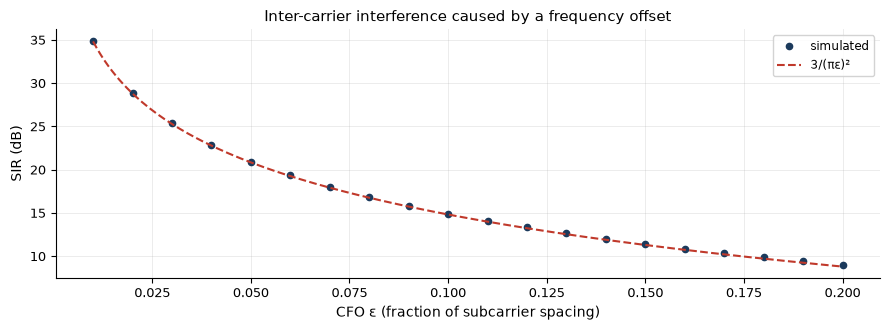

In [11]:
eps = np.linspace(0.01, 0.2, 20)
cfgS = cl.OFDMConfig(256, 200, 16)
g = q16.modulate(cl.random_bits(4 * 200 * 20, rng)).reshape(20, 200)
xs = cl.ofdm_modulate(g, cfgS)
sir = []
for e in eps:
    Ys = cl.ofdm_demodulate(cl.apply_cfo(xs, e / 256), cfgS)
    Ys = Ys * np.exp(-1j * np.angle(np.sum(Ys * np.conj(g), axis=1, keepdims=True)))  # remove common phase
    sir.append(lk.db(1 / np.mean(np.abs(Ys - g) ** 2)))
epf = np.linspace(0.01, 0.2, 200)
f, ax = lk.fig("wide")
ax.plot(eps, sir, "o", label="simulated"); ax.plot(epf, lk.db(3 / (np.pi * epf) ** 2), "--", color=lk.RED, label="3/(πε)²")
ax.set_xlabel("CFO ε (fraction of subcarrier spacing)"); ax.set_ylabel("SIR (dB)"); ax.legend()
ax.set_title("Inter-carrier interference caused by a frequency offset")
lk.show(f)

### Try it yourself 3.1
An NR UE at 3.5 GHz with 30 kHz spacing has a residual CFO of 0.1 ppm of the carrier after
synchronization. What SIR (dB) does the formula predict?

In [13]:
answer_3_1 = None
lk.check("3.1 SIR for 0.1 ppm at 3.5 GHz, 30 kHz SCS", answer_3_1,
         lk.db(3 / (np.pi * 3.5e9 * 0.1e-6 / 30e3) ** 2), atol=0.3, hint="ε = 350 Hz / 30 kHz")

[TODO] 3.1 SIR for 0.1 ppm at 3.5 GHz, 30 kHz SCS: not attempted yet: replace the None with your answer

## 4. Timing and CFO acquisition: the Schmidl & Cox preamble

A training symbol made of two identical halves (length $L$) produces a plateau in
$M(d) = |P(d)|^2/R(d)^2$, where $P(d) = \sum_m r^*_{d+m} r_{d+m+L}$, and the angle of $P$ at the
peak gives the fractional CFO, $\hat\epsilon = \angle P / (2\pi L)$ cycles per sample. 802.11's
short training field and LTE/NR's synchronization signals are relatives of this idea.

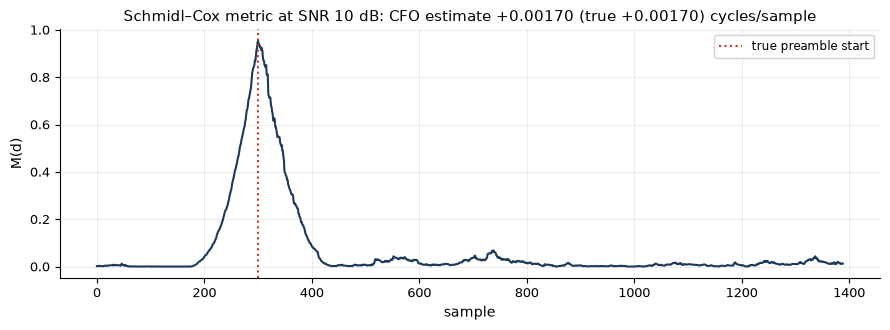

In [15]:
L = 128
half = np.exp(2j * np.pi * rng.random(L))
pre = np.concatenate([half, half])
sig = np.concatenate([np.zeros(300), pre, cl.ofdm_modulate(g[:4], cfgS)])
true_cfo = 0.0017
r_ = cl.awgn(cl.apply_cfo(sig, true_cfo), 10, rng)
M, P = cl.schmidl_cox_metric(r_, L)
d = int(np.argmax(M))
f, ax = lk.fig("wide")
ax.plot(M); ax.axvline(300, color=lk.RED, ls=":", label="true preamble start")
ax.set_xlabel("sample"); ax.set_ylabel("M(d)"); ax.legend()
ax.set_title(f"Schmidl–Cox metric at SNR 10 dB: CFO estimate {np.angle(P[d]) / (2 * np.pi * L):+.5f} "
             f"(true {true_cfo:+.5f}) cycles/sample")
lk.show(f)

**What you should see.** A broad triangular peak centred on the preamble start: timing is found
to within a few samples, and the CFO to about $10^{-5}$ cycles/sample. When the preamble is
preceded by a cyclic prefix the peak becomes a flat plateau as wide as the CP, which is why a
fine-timing step (cross-correlation with the known preamble) usually follows.

## 5. Pilot-based channel estimation

NR embeds DM-RS pilots in the resource grid. Here: comb pilots every $\Delta_p$ subcarriers on
every symbol, least-squares estimates $\hat H_k = Y_k/X_k$ at the pilots, and linear
interpolation between them. The comb must sample $H(f)$ faster than it changes: sparse pilots
fail once $\Delta_p\,\Delta f_{sc}$ approaches the coherence bandwidth.

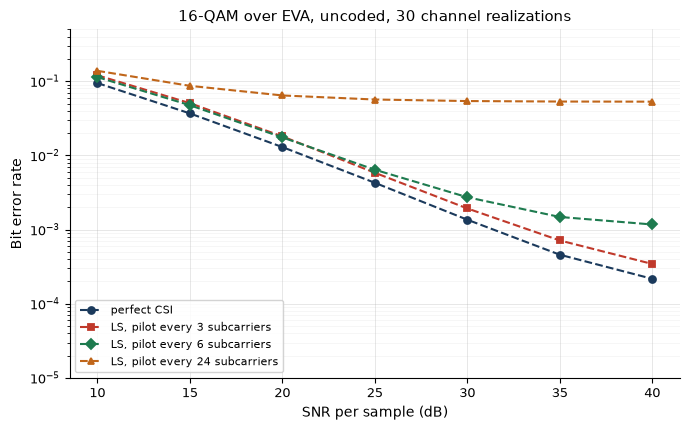

In [18]:
def ber_ofdm(snr_db, spacing, profile="EVA", perfect=False, frames=30, nsym_=4):
    """Average over independent channel realizations; frame i uses seed i so every
    estimator sees identical channels and data."""
    c = cl.OFDMConfig(1024, 600, 72)
    errs = total = 0
    for i in range(frames):
        r = np.random.default_rng(i)
        gg = q16.modulate(cl.random_bits(4 * 600 * nsym_, r)).reshape(nsym_, 600)
        mask = cl.comb_pilot_mask(nsym_, 600, spacing)
        pil = q16.points[0] * np.ones_like(gg)
        gg = np.where(mask, pil, gg)
        xx = cl.ofdm_modulate(gg, c)
        yy, tp = cl.tdl_channel(xx, fs, profile, fd_hz=5, rng=r, return_taps=True)
        yy, n0 = cl.awgn_esn0(yy[:len(xx)], snr_db, rng=r, es=np.mean(np.abs(xx) ** 2))
        YY = cl.ofdm_demodulate(yy, c)
        Htrue = np.array([np.fft.fft(tp[s * c.sym_len + 72], 1024)[c.active] for s in range(nsym_)])
        Hh = Htrue if perfect else cl.ls_channel_estimate(YY, pil, mask)
        e = q16.demodulate(gg[~mask]) != q16.demodulate((YY / Hh)[~mask])
        errs += e.sum(); total += e.size
    return errs / total

snrs = np.arange(10, 41, 5)
sims = {"perfect CSI": [ber_ofdm(s_, 6, perfect=True) for s_ in snrs]}
for sp in [3, 6, 24]:
    sims[f"LS, pilot every {sp} subcarriers"] = [ber_ofdm(s_, sp) for s_ in snrs]
f, ax = lk.fig("ber")
lk.ber_plot(ax, snrs, sims, xlabel="SNR per sample (dB)", ylim=(1e-5, 0.5))
ax.set_title("16-QAM over EVA, uncoded, 30 channel realizations")
lk.show(f)

**What you should see.** Uncoded BER over a frequency-selective Rayleigh channel falls only as
1/SNR: the deeply faded subcarriers dominate. Coding across subcarriers (Labs 8–9) is what
recovers frequency diversity, which is why OFDM is never deployed without FEC. Pilots every
3 subcarriers stay within about 1–2 dB of perfect CSI (noise on the estimates). Every 6 starts
to floor near $10^{-3}$ at high SNR, because linear interpolation cannot follow EVA's deepest
frequency fades. Every 24 subcarriers (360 kHz, comparable to EVA's coherence bandwidth) cannot
follow the channel at all and floors at a few percent.

## 6. PAPR: why the uplink uses DFT-spread OFDM

CP-OFDM's time samples are sums of many independent subcarriers, so they are nearly Gaussian and
their peaks reach 8–10 dB above the mean at the $10^{-3}$ CCDF point. DFT precoding (SC-FDMA,
DFT-s-OFDM) restores a single-carrier envelope and saves several dB of power-amplifier
back-off, which is uplink coverage. LTE uses it for the whole uplink; NR allows it for the uplink
as a coverage option.

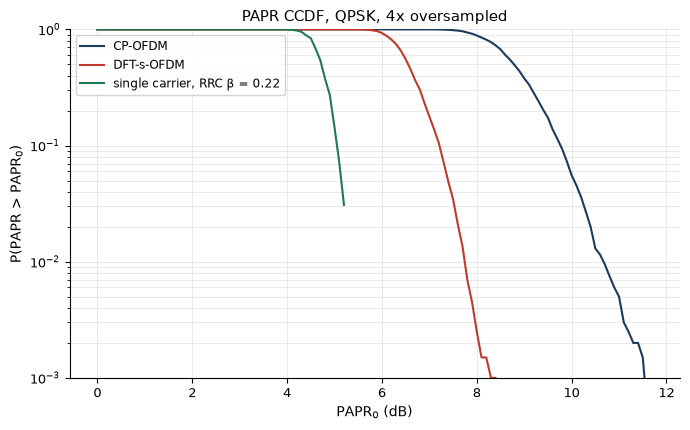

In [21]:
cfgP = cl.OFDMConfig(512, 300, 0)
qp = cl.get_constellation("qpsk")
sym = qp.modulate(cl.random_bits(2 * 300 * 2000, rng))
x_ofdm = cl.ofdm_modulate(sym.reshape(-1, 300), cfgP)
x_dfts = cl.dft_s_ofdm_modulate(sym, cfgP)
os_x = lambda xx: np.fft.ifft(np.fft.fft(xx.reshape(-1, 512), axis=1), 2048, axis=1).ravel()  # 4x oversample
x_sc = cl.shape(sym[:300 * 500], cl.rrc_taps(0.22, 4, 10), 4)
f, ax = lk.fig("ber")
for nm, xx in [("CP-OFDM", os_x(x_ofdm)), ("DFT-s-OFDM", os_x(x_dfts)), ("single carrier, RRC β = 0.22", x_sc[500:-500])]:
    gg, cc = cl.ccdf(cl.papr_db(xx, 2048), np.linspace(0, 12, 121))
    ax.semilogy(gg, np.where(cc > 0, cc, np.nan), label=nm)
ax.set_xlabel("PAPR$_0$ (dB)"); ax.set_ylabel("P(PAPR > PAPR$_0$)"); ax.set_ylim(1e-3, 1); ax.legend()
ax.set_title("PAPR CCDF, QPSK, 4x oversampled"); ax.grid(True, which="both", alpha=0.3)
lk.show(f)

**What you should see.** At the $10^{-3}$ point CP-OFDM needs about 11 dB, DFT-s-OFDM about 8 dB
and filtered single carrier about 5 dB (never exceeded in these windows): 3 dB of PA headroom is roughly a doubling of the uplink
power a handset can deliver at the cell edge.

## 7. 5G NR numerology

Subcarrier spacing $15\cdot 2^\mu$ kHz, 14 symbols per slot (normal CP), a slot of $1/2^\mu$ ms,
12 subcarriers per resource block (3GPP TS 38.211, Section 4).

In [24]:
rows = []
for mu in range(0, 7):
    dd = cl.nr_numerology(mu)
    rows.append([mu, dd["scs_khz"], dd["slot_ms"], dd["useful_symbol_us"], dd["cp_us"], dd["rb_bandwidth_khz"]])
lk.table(rows, ["μ", "SCS (kHz)", "slot (ms)", "symbol (µs)", "CP (µs)", "RB (kHz)"],
         fmt={1: ".0f", 2: ".4f", 3: ".3f", 4: ".3f", 5: ".0f"}, title="NR numerologies (normal CP)")

μ,SCS (kHz),slot (ms),symbol (µs),CP (µs),RB (kHz)
0,15,1.0000,66.667,4.688,180
1,30,0.5000,33.333,2.344,360
2,60,0.2500,16.667,1.172,720
3,120,0.1250,8.333,0.586,1440
4,240,0.0625,4.167,0.293,2880
5,480,0.0312,2.083,0.146,5760
6,960,0.0156,1.042,0.073,11520


### Try it yourself 7.1
The NR normal CP at μ = 1 lasts about 2.34 µs. What is the longest path-length difference (m)
it can absorb? (Light travels 300 m per µs.)

In [26]:
answer_7_1 = None
lk.check("7.1 max excess path length for μ = 1 CP (m)", answer_7_1, cl.nr_numerology(1)["cp_us"] * 1e-6 * 299_792_458,
         rtol=0.02)

[TODO] 7.1 max excess path length for μ = 1 CP (m): not attempted yet: replace the None with your answer

## Key takeaways
* Subcarriers at spacing $1/T$ are orthogonal; the IFFT/FFT pair modulates and separates them.
* A CP longer than the channel memory makes $Y_k = H_kX_k + W_k$: one-tap equalization.
* CFO and Doppler break orthogonality: SIR $\approx 3/(\pi\epsilon)^2$.
* Pilots must sample the channel faster than its coherence bandwidth; uncoded OFDM in fading is
  poor, coded OFDM is excellent.
* CP-OFDM's PAPR (~10 dB) motivates DFT-s-OFDM on the uplink.

## Going further (hardware: USRP B200 / GNU Radio)
* `gnuradio/gr04_ofdm_link.py --sim --multipath --cfo 5000 --snr 20` is an 802.11a-like packet
  OFDM link built from GNU Radio's OFDM blocks. Compare its packet error rate with and without
  `--multipath`, then over the air with the B200 in loopback.
* Capture a Wi-Fi or LTE signal with gr01 and look for the CP: the autocorrelation of the capture
  at lag $N_{\text{FFT}}$ shows a peak every symbol.

## Exercises
1. **(Warm-up)** Prove that circular convolution becomes multiplication in the DFT domain, and
   show why a CP of length ≥ L−1 makes linear convolution circular.
2. **(Core)** Replace the LS estimator with LMMSE interpolation in frequency using the channel's
   frequency correlation $R_{HH}$ (exponential PDP assumption). Plot the gain.
3. **(Core)** Add a Doppler of 5%, 10% and 20% of the subcarrier spacing with `tdl_channel` and
   measure the ICI floor. Compare with Section 3.
4. **(Stretch)** Implement clipping-and-filtering PAPR reduction and plot the trade-off between
   PAPR at $10^{-3}$, EVM and out-of-band emission.

In [28]:
lk.summary()

[good] Lab 07 finished in 19.4 s. Self-checks: 0 passed, 0 failed, 2 still to do.